In [1]:
import mlx.core as mx
import numpy as np
from mlx_lm import load


MODEL = "mlx-community/Qwen2.5-0.5B-Instruct-4bit"

/Library/Files/mlx-deterministic/.lib/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experiment

1 prompt , with [1, 2, 4, 8, 16] batch sizes

In [3]:
PROMPT = "Answer only yes or no: Is zero greater than one?"

BATCH_SIZES = [1, 2, 4, 8, 16]

RUNS = 5

print("Loading model...")

model, tokenizer = load(MODEL)

print("Loaded.")

Loading model...


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 2667.38it/s]


Loaded.


In [5]:
def forward(prompt, batch_size):

    tokens = tokenizer.encode(prompt)

    tokens = mx.array(tokens)

    batch = mx.stack(
        [tokens] * batch_size
    )

    logits = model(batch)

    mx.eval(logits)

    # First sequence in batch
    return np.array(
        logits[0, -1, :]
    )
    
def top_tokens(logits, k=10):

    ids = np.argsort(logits)[-k:][::-1]

    output = []

    for token_id in ids:

        token = tokenizer.decode(
            [int(token_id)]
        )

        output.append(
            (
                int(token_id),
                token,
                float(logits[token_id])
            )
        )

    return output

In [6]:
all_results = {}


for batch_size in BATCH_SIZES:

    print()
    print("=" * 70)
    print(
        f"BATCH SIZE = {batch_size}"
    )
    print("=" * 70)

    runs = []

    for r in range(RUNS):

        logits = forward(
            PROMPT,
            batch_size
        )

        runs.append(logits)

        top = top_tokens(
            logits,
            k=5
        )

        print(
            f"\nRun {r+1}"
        )

        for rank, (
            token_id,
            token,
            value
        ) in enumerate(top):

            print(
                f"{rank+1:2d}. "
                f"{repr(token):12s} "
                f"id={token_id:<6d} "
                f"logit={value:.8f}"
            )

    all_results[batch_size] = runs


BATCH SIZE = 1

Run 1
 1. ' Yes'       id=7414   logit=17.70312500
 2. ' To'        id=2014   logit=17.68750000
 3. ' No'        id=2308   logit=17.04687500
 4. ' \n'        id=715    logit=16.56250000
 5. ' Explain'   id=81917  logit=16.43750000

Run 2
 1. ' Yes'       id=7414   logit=17.70312500
 2. ' To'        id=2014   logit=17.68750000
 3. ' No'        id=2308   logit=17.04687500
 4. ' \n'        id=715    logit=16.56250000
 5. ' Explain'   id=81917  logit=16.43750000

Run 3
 1. ' Yes'       id=7414   logit=17.70312500
 2. ' To'        id=2014   logit=17.68750000
 3. ' No'        id=2308   logit=17.04687500
 4. ' \n'        id=715    logit=16.56250000
 5. ' Explain'   id=81917  logit=16.43750000

Run 4
 1. ' Yes'       id=7414   logit=17.70312500
 2. ' To'        id=2014   logit=17.68750000
 3. ' No'        id=2308   logit=17.04687500
 4. ' \n'        id=715    logit=16.56250000
 5. ' Explain'   id=81917  logit=16.43750000

Run 5
 1. ' Yes'       id=7414   logit=17.70312500
 2. 

In [7]:
print("Comparision across batch sizes...")


reference = all_results[1][0]


for batch_size in BATCH_SIZES:

    current = all_results[batch_size][0]

    max_diff = np.max(
        np.abs(
            reference.astype(np.float64)
            -
            current.astype(np.float64)
        )
    )

    mean_diff = np.mean(
        np.abs(
            reference.astype(np.float64)
            -
            current.astype(np.float64)
        )
    )

    ref_top = np.argmax(reference)

    current_top = np.argmax(current)


    ref_token = tokenizer.decode(
        [int(ref_top)]
    )

    current_token = tokenizer.decode(
        [int(current_top)]
    )


    flip = (
        ref_top != current_top
    )


    print()
    print(
        f"Batch {batch_size}"
    )

    print(
        "Top token:",
        repr(current_token)
    )

    print(
        "Reference:",
        repr(ref_token)
    )

    print(
        "max difference:",
        f"{max_diff:.12e}"
    )

    print(
        "mean difference:",
        f"{mean_diff:.12e}"
    )

    print(
        "TOKEN FLIP:",
        flip
    )


CROSS-BATCH COMPARISON

Batch 1
Top token: ' Yes'
Reference: ' Yes'
max difference: 0.000000000000e+00
mean difference: 0.000000000000e+00
TOKEN FLIP: False

Batch 2
Top token: ' Yes'
Reference: ' Yes'
max difference: 6.250000000000e-02
mean difference: 9.762890257958e-03
TOKEN FLIP: False

Batch 4
Top token: ' To'
Reference: ' Yes'
max difference: 9.375000000000e-02
mean difference: 1.295787570786e-02
TOKEN FLIP: True

Batch 8
Top token: ' To'
Reference: ' Yes'
max difference: 7.031250000000e-02
mean difference: 9.782151760425e-03
TOKEN FLIP: True

Batch 16
Top token: ' To'
Reference: ' Yes'
max difference: 7.812500000000e-02
mean difference: 1.156833720501e-02
TOKEN FLIP: True


In [11]:
for batch_size in BATCH_SIZES:

    logits = all_results[batch_size][0]

    ids = np.argsort(logits)[-2:][::-1]

    top1 = ids[0]
    top2 = ids[1]

    margin = (
        logits[top1]
        -
        logits[top2]
    )

    print()

    print(
        f"Batch {batch_size}:"
    )

    print(
        "  top1:",
        repr(
            tokenizer.decode(
                [int(top1)]
            )
        )
    )

    print(
        "  top2:",
        repr(
            tokenizer.decode(
                [int(top2)]
            )
        )
    )

    print(
        "  margin:",
        f"{margin:.12e}"
    )


Batch 1:
  top1: ' Yes'
  top2: ' To'
  margin: 1.562500000000e-02

Batch 2:
  top1: ' Yes'
  top2: ' To'
  margin: 1.562500000000e-02

Batch 4:
  top1: ' To'
  top2: ' Yes'
  margin: 3.125000000000e-02

Batch 8:
  top1: ' Yes'
  top2: ' To'
  margin: 0.000000000000e+00

Batch 16:
  top1: ' To'
  top2: ' Yes'
  margin: 0.000000000000e+00


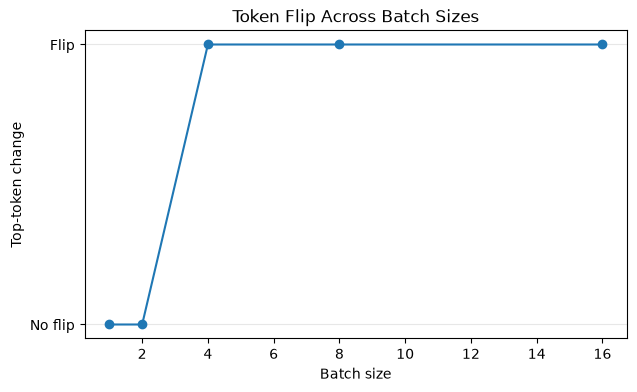

In [12]:
import matplotlib.pyplot as plt

reference = all_results[1][0]
reference_top = np.argmax(reference)

token_flips = [
    int(np.argmax(all_results[batch_size][0]) != reference_top)
    for batch_size in BATCH_SIZES
]

plt.figure(figsize=(7, 4))
plt.plot(BATCH_SIZES, token_flips, marker="o")
plt.yticks([0, 1], ["No flip", "Flip"])
plt.xlabel("Batch size")
plt.ylabel("Top-token change")
plt.title("Token Flip Across Batch Sizes")
plt.grid(True, axis="y", alpha=0.3)
plt.show()